In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def polynomial_transform(value):
    deg_5=np.exp(value,1/5)
    return np.array(deg_5)

In [3]:
i=3.55

In [4]:


def DOM(data):

    df=pd.read_parquet(data,engine='fastparquet')

    ## Date feature
    df['date']=df['timestamp'].apply(lambda x: x.split(' ')[0])

    ## Transforming population with log
    df['PB']=df['PB'].apply(np.log10)
    df['PS']=df['PB'].apply(np.log10)
    df['CB']=df['PB'].apply(np.log10)
    df['CS']=df['PB'].apply(np.log10)

    #df['PB']=df['PB']+df['CS']
    #df['CB']=df['CB']+df['PS']

    ## Dropping CS and PS
    #df.drop(['CS',PS],axis=1,inplace=True)

    ## Velocity Instantaneuos CB PB
    df['CB_vel_inst']=df['CB'].diff()
    df['PB_vel_inst']=df['PB'].diff()
    df['CS_vel_inst']=df['CB'].diff()
    df['PS_vel_inst']=df['PB'].diff()

    ## Velocity CB PB Mean
    #df['CB_vel_mean']=df['CB_vel_inst'].rolling(30).sum()
    #df['PB_vel_mean']=df['PB_vel_inst'].rolling(30).sum()

    ## Difference of PB and CB Velocities Instantaneous and Mean
    #df['diff_of_vel_inst_B']=df['CB_vel_inst']-df['PB_vel_inst']
    #df['diff_of_vel_inst_S']=df['PS_vel_inst']-df['CS_vel_inst']
    #df['diff_of_vel_mean']=df['diff_of_vel_inst'].rolling(30).mean()

    ## Acceleration
    #df['PB_acc_inst']=df['PB_vel_inst'].diff()
    #df['CB_acc_inst']=df['CB_vel_inst'].diff()
    #df['PS_acc_inst']=df['PS_vel_inst'].diff()
    #df['CS_acc_inst']=df['CS_vel_inst'].diff()
    #df['diff_CB_PB_acc_inst']=df['CB_acc_inst']-df['PB_acc_inst']

    # Rolling mean acceleration (window = 30)
    #df['PB_acc_mean'] = df['PB_acc_inst'].rolling(30).sum()
    #df['CB_acc_mean'] = df['CB_acc_inst'].rolling(30).sum()
    #df['diff_CB_PB_mean']=df['CB_acc_mean']-df['PB_acc_mean']

    ## Population difference Instantaneous and Mean
    df['population_diff_inst_CB_CS']=df['CB']-df['CS']
    df['population_diff_inst_PS_PB']=df['PS']-df['PB']
    #df['population_diff_mean']=df['population_diff_inst'].rolling(30).mean()

    ## Weightage of Population Instaneous and Mean
    #df['weightage_inst']=df['population_diff_inst']/(df['PB']+df['CB'])
    #df['weightage_mean']=df['weightage_inst'].rolling(30).mean()

    ## Price velocity
    #df['Price_vel_inst']=df['P'].diff()
    #df['Price_vel_mean']=df['Price_vel_inst'].rolling(30).mean()

    ## Price acceleration
    #df['Price_acc_inst']=df['Price_vel_inst'].diff()
    #df['Price_acc_mean']=df['Price_acc_inst'].rolling(30).mean()

    ## Mean Price of previous 5 mins
    #df['Price_mean_prev_5_min']=df['P'].rolling(30).mean()

    ## Variance Price of previous 5 mins
    #df['Price_variance_prev_5_min']=df['P'].rolling(30).var()

    ## Median Price of previous 5 mins
    #df['Price_median_prev_5_min']=df['P'].rolling(30).median()
    
    ## Max initial value from the first 5 mins
    max_init_val=df['P'][0:29].max()
    #df['max_init_val']=max_init_val

    ## Min initial value from the first 5 mins
    min_init_val=df['P'][0:29].min()
    #df['min_init_val']=min_init_val

    ## Initial Population 
    #df['init_population_total']=df['PB'][0]+df['CB'][0]+df['PS'][0]+df['CS'][0]
    #df['init_population_PB']=df['PB'][0]
    #df['init_population_CB']=df['CB'][0]

    ## Initial Population Mean
    #df['init_population_mean_total']=(df['PB'].rolling(30).mean()+df['CB'].rolling(30).mean())[29]
    #df['init_population_mean_PB']=df['PB'].rolling(30).mean()[29]
    #df['init_population_mean_CB']=df['CB'].rolling(30).mean()[29]

    ''' ## Future Price 
    df['future_price']=df['P'].iloc[::-1].rolling(30).mean().shift(1).iloc[::-1]
    df['price_change']=df['future_price']-df['P']
    df['sign']=df['price_change'].apply(lambda x: 1 if x>0 else 0)
    df.drop(['price_change','future_price'],axis=1,inplace=True)'''



    ## Resistance and Support Levels
    pos09=max_init_val+(0.09*max_init_val/100)
    pos18=pos09+(0.18*max_init_val/100)
    pos27=pos18+(0.27*max_init_val/100)
    pos36=pos27+(0.36*max_init_val/100)
    pos45=pos36+(0.45*max_init_val/100)
    pos54=pos45+(0.54*max_init_val/100)
    pos63=pos54+(0.63*max_init_val/100)
    pos72=pos63+(0.72*max_init_val/100)

    neg09=min_init_val-(0.09*min_init_val/100)
    neg18=neg09-(0.18*min_init_val/100)
    neg27=neg18-(0.27*min_init_val/100)
    neg36=neg27-(0.36*min_init_val/100)
    neg45=neg36-(0.45*min_init_val/100)
    neg54=neg45-(0.54*min_init_val/100)
    neg63=neg54-(0.63*min_init_val/100)
    neg72=neg63-(0.72*min_init_val/100)


    ## Points of Deflection
    points_of_deflection={+1: max_init_val, +9: pos09, +18:pos18, +27: pos27, +36: pos36, +45: pos45, +54:pos54, +63: pos63, +72: pos72, -1: min_init_val, -9: neg09, -18: neg18, -27: neg27, -36: neg36, -45: neg45, -54: neg54, -63: neg63, -72: neg72}
    
    error=5
    df['Flag']=0
    for key,value in points_of_deflection.items():
        mask=(df['P']>=value-error) & (df['P']<=value+error)
        #df.loc[mask,'point']=key
        df.loc[mask,'Flag']=1
        #df.loc[mask,'point_price']=value
        
    ## Price transform
    df['P']=df['P'].apply(lambda x: x**(i))
    #df['P']=df['P'].apply(lambda x: np.log10(x))
    
    return df
    


In [5]:
np.log(4)

1.3862943611198906

In [6]:
np.log10(4)

0.6020599913279624

In [7]:
np.log2(4)

2.0

In [8]:

df1=DOM('data (1).parquet')
df2=DOM('data (1)(1).parquet')
df3=DOM('data (2) (1).parquet')
df4=DOM('data (2).parquet')
df5=DOM('data (3).parquet')
df6=DOM('data (4).parquet')
df7=DOM('data (5).parquet')
df8=DOM('data (6) (1).parquet')
df9=DOM('data (6).parquet')
df10=DOM('data (7).parquet')
df11=DOM('data (8).parquet')
df12=DOM('data (9).parquet')
df13=DOM('data (10).parquet')
df14=DOM('data (11).parquet')
df15=DOM('data (12).parquet')
df16=DOM('data (14).parquet')
df17=DOM('data (15).parquet')
df18=DOM('data.parquet')

In [9]:
df19=DOM('2026-06-15_NIFTY_2026-06-16_data.parquet')
df20=DOM('2026-06-16_NIFTY_2026-06-16_data.parquet')
df21=DOM('2026-06-17_NIFTY_2026-06-23_data.parquet')
df22=DOM('2026-06-22_NIFTY_2026-06-23_data.parquet')
df23=DOM('2026-06-23_NIFTY_2026-06-23_data.parquet')
df24=DOM('2026-06-24_NIFTY_2026-06-30_data.parquet')
df25=DOM('2026-06-25_NIFTY_2026-06-30_data.parquet')
df26=DOM('2026-06-29_NIFTY_2026-06-30_data.parquet')
df27=DOM('2026-07-01_NIFTY_2026-07-07_data.parquet')
df28=DOM('2026-07-02_NIFTY_2026-07-07_data.parquet')
df29=DOM('2026-07-03_NIFTY_2026-07-07_data.parquet')
df30=DOM('2026-07-06_NIFTY_2026-07-07_data.parquet')
df31=DOM('2026-07-07_NIFTY_2026-07-07_data.parquet')
df32=DOM('2026-07-08_NIFTY_2026-07-14_data.parquet')
df33=DOM('2026-07-09_NIFTY_2026-07-14_data.parquet')
df34=DOM('2026-07-10_NIFTY_2026-07-14_data.parquet')
df35=DOM('2026-06-30_NIFTY_2026-06-30_data.parquet')


In [10]:
dfs=[df1,df2,df3,df4,df5,df6,df7,df26,df27,df28,df29,df30,df31,df32,df33,df34,df35,df23,df24,df25,df8,df9,df10,df11,df12,df13,df14,df15,df16,df17,df18]
dfs_check=[df19,df20,df21,df22]


In [11]:
init_prices=[]
for df in dfs:
    init_prices.append(df['P'][180])

for df in dfs_check:
    init_prices.append(df['P'][180])

<Axes: ylabel='Count'>

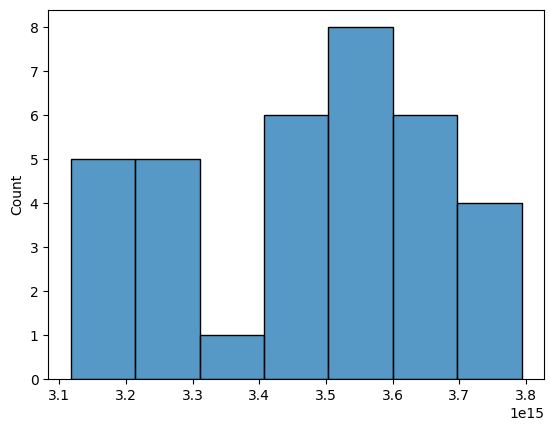

In [12]:
sns.histplot(init_prices)

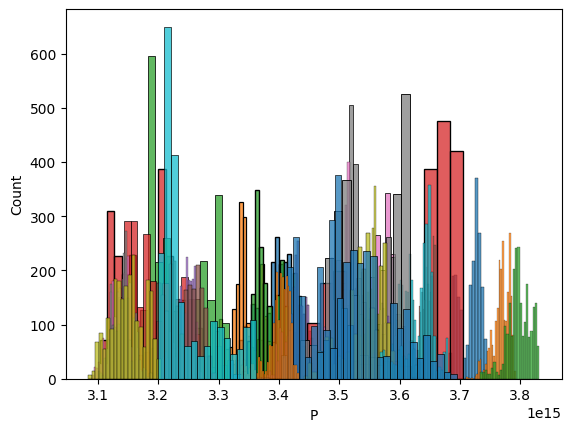

In [13]:
for df in dfs:
    sns.histplot(df['P'])



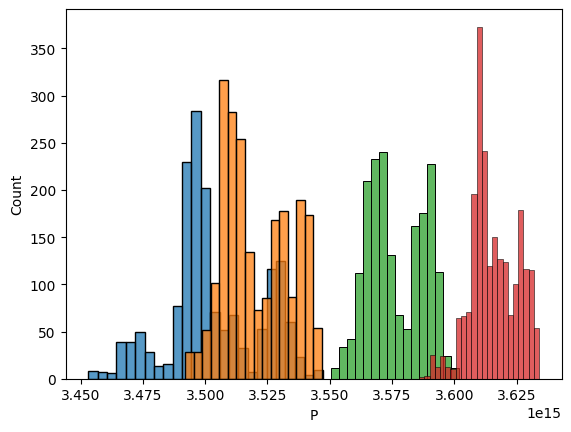

In [14]:
for df in dfs_check:
    sns.histplot(df['P'])

In [15]:
for df in dfs:
    ## Dropping timestamps
    #df.drop('timestamp',axis=1,inplace=True)

    ## Removing first 5 mins data
    df.drop(index=[i for i in range(0,2)],inplace=True)

    ## Keeping only points touching levels
    #df.drop(index=[i for i in df[df['Flag']==0].index],inplace=True)

    ## Removing Flag column
    #df.drop('Flag',axis=1,inplace=True)

    ## Removing last point since na future value
     #df.dropna(inplace=True)

    #df['point_price']=df['point_price'].fillna(0)
    #df['point']=df['point'].fillna(0)


In [16]:
for df in dfs_check:
    ## Dropping timestamps
    #df.drop('timestamp',axis=1,inplace=True)

    ## Removing first 5 mins data
    df.drop(index=[i for i in range(0,31)],inplace=True)

    ## Keeping only points touching levels
    #df.drop(index=[i for i in df[df['Flag']==0].index],inplace=True)

    ## Removing Flag column
    #df.drop('Flag',axis=1,inplace=True)

    ## Removing last point since na future value
     #df.dropna(inplace=True)

    #df['point_price']=df['point_price'].fillna(0)
    #df['point']=df['point'].fillna(0)


In [17]:
df=pd.concat([df1,df2,df3,df4,df5,df6,df7,df26,df27,df28,df29,df30,df31,df32,df33,df34,df35,df23,df24,df25,df8,df9,df10,df11,df12,df13,df14,df15,df16,df17,df18])

In [18]:

df_check=pd.concat([df19,df20,df21,df22])


<Axes: xlabel='P', ylabel='Count'>

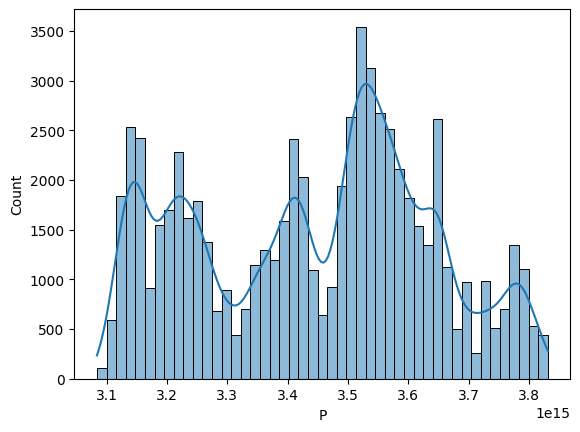

In [19]:
sns.histplot(df['P'],kde=True)

<Axes: xlabel='P', ylabel='Count'>

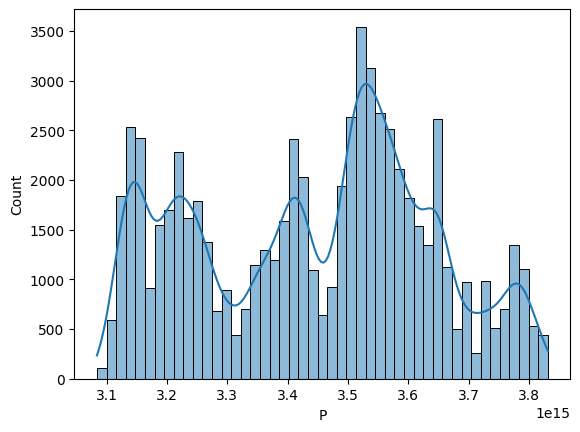

In [20]:
sns.histplot(df['P'],kde=True)

<Axes: xlabel='P', ylabel='Density'>

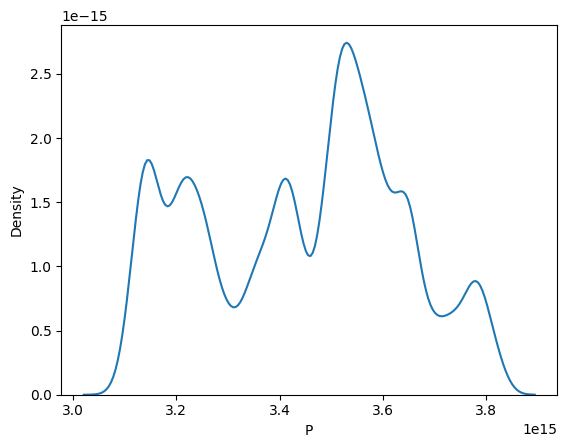

In [21]:
sns.kdeplot(df['P'])

In [22]:
df.head()

,timestamp,P,CB,PS,CS,PB,date,CB_vel_inst,PB_vel_inst,CS_vel_inst,PS_vel_inst,population_diff_inst_CB_CS,population_diff_inst_PS_PB,Flag
2,2026-03-12 09:15:20,3.354364e+15,0.795354,0.795354,0.795354,6.242440,2026-03-12,0.004386,0.062730,0.004386,0.062730,0.0,-5.447085,0
3,2026-03-12 09:15:30,3.346760e+15,0.794779,0.794779,0.794779,6.234172,2026-03-12,-0.000576,-0.008268,-0.000576,-0.008268,0.0,-5.439393,0
4,2026-03-12 09:15:40,3.337612e+15,0.798802,0.798802,0.798802,6.292186,2026-03-12,0.004023,0.058015,0.004023,0.058015,0.0,-5.493385,0
5,2026-03-12 09:15:50,3.334825e+15,0.798962,0.798962,0.798962,6.294514,2026-03-12,0.000161,0.002327,0.000161,0.002327,0.0,-5.495551,0
6,2026-03-12 09:16:00,3.333621e+15,0.797180,0.797180,0.797180,6.268732,2026-03-12,-0.001782,-0.025781,-0.001782,-0.025781,0.0,-5.471553,0


In [23]:
'''def create_nonoverlapping_windows_by_day(df,window_size,forecast_horizon=3,stride=6):
    X,Y,dates=[],[],[]

    for date,day_data in df.groupby('date'):
        feature_cols=[col for col in df.columns if col not in ['timestamp','date']]
        day_features=day_data[feature_cols].values
        

        n_samples=len(day_features)
        #print(f'n_samples:{n_samples}')
        # change stride for hypaer parameter
        for start_idx in range(0, n_samples-window_size-forecast_horizon+1,stride):
            end_idx=start_idx+window_size
            target_start=end_idx
            target_end=target_start+forecast_horizon

            if target_end<=n_samples:
                #X.append(day_features[start_idx:end_idx])
                ## assuming first column is target 00
                Y.append(day_features[target_start:target_end,0])
                #dropping Price column
                feature_cols=[col for col in df.columns if col not in ['timestamp','date','P']]
                day_features=day_data[feature_cols].values
                X.append(day_features[start_idx:end_idx])
        

                dates.append(date)
    print(len(X))
    #print(X[0][0][-1])
    #print(f'X:{X}')
    #print(f'Y:{Y}')
    return np.array(X),np.array(Y),np.array(dates)'''

"def create_nonoverlapping_windows_by_day(df,window_size,forecast_horizon=3,stride=6):\n    X,Y,dates=[],[],[]\n\n    for date,day_data in df.groupby('date'):\n        feature_cols=[col for col in df.columns if col not in ['timestamp','date']]\n        day_features=day_data[feature_cols].values\n        \n\n        n_samples=len(day_features)\n        #print(f'n_samples:{n_samples}')\n        # change stride for hypaer parameter\n        for start_idx in range(0, n_samples-window_size-forecast_horizon+1,stride):\n            end_idx=start_idx+window_size\n            target_start=end_idx\n            target_end=target_start+forecast_horizon\n\n            if target_end<=n_samples:\n                #X.append(day_features[start_idx:end_idx])\n                ## assuming first column is target 00\n                Y.append(day_features[target_start:target_end,0])\n                #dropping Price column\n                feature_cols=[col for col in df.columns if col not in ['timestamp','dat

In [24]:
def create_nonoverlapping_windows_by_day(df,window_size,forecast_horizon=1,stride=1):
    X,Y,Y_5_min,dates=[],[],[],[]


    for date,day_data in df.groupby('date'):
        feature_cols=[col for col in df.columns if col not in ['timestamp','date']]
        day_features=day_data[feature_cols].values

        #print(day_data.head())
        ## indexes with touching point
        touch_indices=day_data[day_data['Flag']==1].index
        feature_cols=[col for col in df.columns if col not in ['timestamp','date','Flag']]
        day_features=day_data[feature_cols].values
        #print(touch_indices)
        print(stride)

        n_samples=len(day_features)
        #print(f'n_samples:{n_samples}')
        # change stride for hypaer parameter
        for end_idx in touch_indices:
            if (end_idx-window_size>0)&(end_idx+forecast_horizon+29<n_samples):
                start_idx=end_idx-window_size
                target_start=end_idx+1
                target_end=target_start+forecast_horizon

                if target_end<=n_samples:
                    feature_cols=[col for col in df.columns if col not in ['timestamp','date','Flag']]
                    day_features=day_data[feature_cols].values
                    X.append(day_features[start_idx:end_idx])
                    ## assuming first column is target 00     
                    feature_cols=[col for col in df.columns if col in ['P']]
                    day_features=day_data[feature_cols].values                   
                    Y.append(day_features[target_start:target_end,0])
                    Y_5_min.append(day_features[target_start:target_start+30,0])
                    #dropping Price column
                    #feature_cols=[col for col in df.columns if col not in ['timestamp','P','date','Flag']]
                    #day_features=day_data[feature_cols].values
                    #X.append(day_features[start_idx:end_idx])

                    dates.append(date)
        

        '''for start_idx in range(0, n_samples-window_size-forecast_horizon+1,stride):
            end_idx=start_idx+window_size
            target_start=end_idx
            target_end=target_start+forecast_horizon

            if target_end<=n_samples:
                #X.append(day_features[start_idx:end_idx])
                ## assuming first column is target 00
                Y.append(day_features[target_start:target_end,0])
                #dropping Price column
                feature_cols=[col for col in df.columns if col not in ['timestamp','date','P']]
                day_features=day_data[feature_cols].values
                X.append(day_features[start_idx:end_idx])
        

                dates.append(date)'''
    #print(len(X))
    #print(X[0][0][-1])
    #print(f'X:{X}')
    #print(f'Y:{Y}')
    return np.array(X),np.array(Y),np.array(dates),np.array(Y_5_min)

In [25]:
def prepare_targets_single_step(y_multi):
    return y_multi[:,0]

def prepare_targets_multi_step(y_multi):
    return y_multi

In [26]:
def visualize_windows(x,y,df,n_windows=3):
    fig,axes=plt.subplots(n_windows,1,figsize=(12,8))

    for i in range(min(n_windows,len(x))):
        ax=axes[i] if n_windows>1 else axes

        ax.plot(x[i,:,0], marker='o',label='Input window')
        ax.axhline(y=y[i],color='r',linestyle='--',label=f'Target: {y[i]:.2f}')
        ax.set_title(f'Window {i+1}')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Feature Value')
        ax.legend()
        ax.grid(True,alpha=0.3)

    plt.tight_layout()
    



In [27]:
def normalize_data(x_train,x_test,feature_wise=True):

    n_samples,n_timesteps,n_features=x_train.shape

    if feature_wise:
        x_train_flat=x_train.reshape(-1,n_features)
        x_test_flat=x_test.reshape(-1,n_features)

        scaler=StandardScaler()
        x_train_scaled=scaler.fit_transform(x_train_flat)
        x_test_scaled=scaler.transform(x_test_flat)

        x_train_scaled=x_train_scaled.reshape(n_samples,n_timesteps,n_features)
        x_test_scaled=x_test_scaled.reshape(x_test.shape)

        return x_train_scaled,x_test_scaled,scaler

    else:
        return
    

In [28]:
def train_test_split_time_series(x,y, dates,y_5_min,train_ratio=0.8,by_date=True):
    print(y_5_min.shape)
    if by_date:
        unique_dates=np.unique(dates)
        #print(f'unique_dates:{unique_dates}')
        split_idx=int(len(unique_dates)*train_ratio)
        #print(f'split_idx:{split_idx}')
        train_dates=unique_dates[:split_idx]
        #print(f'train_dates:{train_dates}')

        train_mask=np.isin(dates,train_dates)
        #print(f'train_mask:{train_mask}')
        test_mask=~train_mask
        print(f'y:{y}')
        

        x_train,x_test=x[train_mask],x[test_mask]
        y_train,y_test=y[train_mask],y[test_mask]
        y_5_min_train,y_5_min_test=y_5_min[train_mask],y_5_min[test_mask]

    else:
        split_idx=int(len(x)*train_ratio)
        x_train,x_test=x[:split_idx],x[split_idx:]
        y_train,y_test=y[:split_idx],y[split_idx:]
        y_5_min_train,y_5_min_test=y_5_min_train[:split_idx],y_5_min_test[split_idx:]
    #print(f'x_train:{x_train}')
    #print(f'x_test:{x_test}')

    return x_train,x_test,y_train,y_test,y_5_min_train,y_5_min_test


In [29]:
def normalize_data_check(x_check_train,scaler,feature_wise=True):

    n_samples,n_timesteps,n_features=x_check_train.shape

    if feature_wise:
        x_check_train_flat=x_check_train.reshape(-1,n_features)

        x_check_train_scaled=scaler.transform(x_check_train_flat)

        x_check_train_scaled=x_check_train_scaled.reshape(n_samples,n_timesteps,n_features)


    return x_check_train_scaled,scaler

In [30]:
'''def main():
    print('='*70)
    print('TIME SERIES SLIDING WINDOWS PIPELINE')
    print('='*70)

    print('\n1. Creating Sampling Data...')
    df
    window_size=30
    forecast_horizon=1

    

    print(f'2. Creating Non-Overlapping windows(by day)...')
    print(f'Window size:{window_size} timesteps')
    print(f' Forecast horion: {forecast_horizon} timesteps')

    x,y_multi,dates,Y_5_min=create_nonoverlapping_windows_by_day(df,window_size=window_size,forecast_horizon=forecast_horizon)
    print(f'y_multi:{y_multi}')
    print(f'Generated {x.shape[0]} windows')
    print(f'x shape:{x.shape}(samples,timesteps,features)')
    print(f'y shape (multi-step): {y_multi.shape}\n')

    print('3. Target Strategy Options:')
    print(' Option A: Single-step (predict only next value)')
    y_single=prepare_targets_single_step(y_multi)
    print(f'y_single shape: {y_single.shape}')

    print(' Option B: multi-step (predict sequence of future values)')
    y_multi=prepare_targets_multi_step(y_multi)
    print(f'y_multi shape: {y_multi.shape}')

    ## choose one
    y=y_single
    print(f'y:{y}')
    #y=y_multi


    print('4 Train-Test Split(time-safe)...')
    x_train,x_test,y_train,y_test=train_test_split_time_series(x,y,dates,Y_5_min,train_ratio=0.8,by_date=True)


    print(f' Train size {x_train.shape[0]} windows({x_train.shape[0]/len(x)*100:.1f}%')
    print(f' Test size {x_test.shape[0]} windows({x_test.shape[0]/len(x)*100:.1f}%')
    print(f'x_train shape:{x_train.shape}')
    print(f'y_train shape: {y_train.shape}\n')


    print('5 Normalizing features...')
    x_train_scaled,x_test_scaled,scaler=normalize_data(x_train,x_test,feature_wise=True)
    print(f'Scaler fitted on training data')  
    print(f'Mean(train) :{x_train_scaled.mean():.4f}')  
    print(f'Std(train) :{x_train_scaled.std():.4f}\n')  


    print('6 Ready for model training!')  
    print(f'Input features: {x_train_scaled.shape[2]}')  
    print(f'Sequence Length: {x_train_scaled.shape[1]}')  
    print(f'Samples: {x_train_scaled.shape[0]}')  
    print(f'Output: Single value per sample')  

    return x_train_scaled,x_test_scaled,y_train,y_test,scaler,df'''

"def main():\n    print('='*70)\n    print('TIME SERIES SLIDING WINDOWS PIPELINE')\n    print('='*70)\n\n    print('\n1. Creating Sampling Data...')\n    df\n    window_size=30\n    forecast_horizon=1\n\n    \n\n    print(f'2. Creating Non-Overlapping windows(by day)...')\n    print(f'Window size:{window_size} timesteps')\n    print(f' Forecast horion: {forecast_horizon} timesteps')\n\n    x,y_multi,dates,Y_5_min=create_nonoverlapping_windows_by_day(df,window_size=window_size,forecast_horizon=forecast_horizon)\n    print(f'y_multi:{y_multi}')\n    print(f'Generated {x.shape[0]} windows')\n    print(f'x shape:{x.shape}(samples,timesteps,features)')\n    print(f'y shape (multi-step): {y_multi.shape}\n')\n\n    print('3. Target Strategy Options:')\n    print(' Option A: Single-step (predict only next value)')\n    y_single=prepare_targets_single_step(y_multi)\n    print(f'y_single shape: {y_single.shape}')\n\n    print(' Option B: multi-step (predict sequence of future values)')\n    y_mu

In [31]:
'''x_train_scaled,x_test_scaled,y_train,y_test,scaler,df=main()
visualize_windows(x_test_scaled[:3],y_test[:3],df,n_windows=3)'''

'x_train_scaled,x_test_scaled,y_train,y_test,scaler,df=main()\nvisualize_windows(x_test_scaled[:3],y_test[:3],df,n_windows=3)'

In [32]:
def main_check():
    print('='*70)
    print('TIME SERIES SLIDING WINDOWS PIPELINE')
    print('='*70)

    print('\n1. Creating Sampling Data...')
    df
    df_check
    window_size=30
    forecast_horizon=1

    

    print(f'2. Creating Non-Overlapping windows(by day)...')
    print(f'Window size:{window_size} timesteps')
    print(f' Forecast horion: {forecast_horizon} timesteps')

    x,y_multi,dates,Y_5_min=create_nonoverlapping_windows_by_day(df,window_size=window_size,forecast_horizon=forecast_horizon)
    print(f'y_multi:{y_multi}')
    print(f'Generated {x.shape[0]} windows')
    print(f'x shape:{x.shape}(samples,timesteps,features)')
    print(f'y shape (multi-step): {y_multi.shape}\n')

    x_check,y_check_multi,dates_check,Y_5_min_check=create_nonoverlapping_windows_by_day(df_check,window_size=window_size,forecast_horizon=forecast_horizon)
    print(f'y_check_multi:{y_check_multi}')
    print(f'Generated check {x_check.shape[0]} windows')
    print(f'x_check shape:{x_check.shape}(samples,timesteps,features)')
    print(f'y check shape (multi-step): {y_check_multi.shape}\n')





    print('3. Target Strategy Options:')
    print(' Option A: Single-step (predict only next value)')
    y_single=prepare_targets_single_step(y_multi)
    print(f'y_single shape: {y_single.shape}')

    print(' Option B: multi-step (predict sequence of future values)')
    y_multi=prepare_targets_multi_step(y_multi)
    print(f'y_multi shape: {y_multi.shape}')

    print('Check Option A: Single-step (predict only next value)')
    y_check_single=prepare_targets_single_step(y_check_multi)
    print(f'y_single shape: {y_single.shape}')

    print('Check Option B: multi-step (predict sequence of future values)')
    y_check_multi=prepare_targets_multi_step(y_check_multi)
    print(f'y_multi shape: {y_multi.shape}')

    ## choose one
    y=y_single
    print(f'y:{y}')
    y_check=y_check_single
    print(f'y_check:{y_check}')
    #y=y_multi






    print('4 Train-Test Split(time-safe)...')
    x_train,x_test,y_train,y_test,y_5_min_train,y_5_min_test=train_test_split_time_series(x,y,dates,Y_5_min,train_ratio=0.8,by_date=True)
    x_check_train,x_check_test,y_check_train,y_check_test,y_5_min_train_check,y_5_min_test_check=train_test_split_time_series(x_check,y_check,dates_check,Y_5_min_check,train_ratio=1,by_date=True)


    print(f' Train size {x_train.shape[0]} windows({x_train.shape[0]/len(x)*100:.1f}%')
    print(f' Test size {x_test.shape[0]} windows({x_test.shape[0]/len(x)*100:.1f}%')
    print(f'x_train shape:{x_train.shape}')
    print(f'y_train shape: {y_train.shape}\n')

    print(f' Check Train size {x_check_train.shape[0]} windows({x_check_train.shape[0]/len(x)*100:.1f}%')
    print(f'x_check_train shape:{x_check_train.shape}')
    print(f'y_check_train shape: {y_check_train.shape}\n')








    print('5 Normalizing features...')
    x_train_scaled,x_test_scaled,scaler=normalize_data(x_train,x_test,feature_wise=True)
    print(f'Scaler fitted on training data')  
    print(f'Mean(train) :{x_train_scaled.mean():.4f}')  
    print(f'Std(train) :{x_train_scaled.std():.4f}\n')  

    x_check_train_scaled,scaler=normalize_data_check(x_check_train,scaler,feature_wise=True)
    print(f'Scaler fitted on Check training data')  
    print(f'Mean check (train) :{x_check_train_scaled.mean():.4f}')  
    print(f'Std check (train) :{x_check_train_scaled.std():.4f}\n') 




    print('6 Ready for model training!')  
    print(f'Input features: {x_train_scaled.shape[2]}')  
    print(f'Sequence Length: {x_train_scaled.shape[1]}')  
    print(f'Samples: {x_train_scaled.shape[0]}')  
    print(f'Output: Single value per sample')  


    print(f'Input check features: {x_check_train_scaled.shape[2]}') 
    print(f'Sequence check Length: {x_check_train_scaled.shape[1]}')  
    print(f'Samples check: {x_check_train_scaled.shape[0]}')  
    print(f'Output check: Single value per sample') 


    return x_train_scaled,x_test_scaled,y_train,y_test,y_5_min_train,y_5_min_test,scaler,df,x_check_train_scaled,y_check_train,y_5_min_train_check,df_check

TIME SERIES SLIDING WINDOWS PIPELINE

1. Creating Sampling Data...
2. Creating Non-Overlapping windows(by day)...
Window size:30 timesteps
 Forecast horion: 1 timesteps
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
y_multi:[[3.66235890e+15]
 [3.65455410e+15]
 [3.65664494e+15]
 ...
 [3.65857570e+15]
 [3.65747615e+15]
 [3.65720800e+15]]
Generated 16261 windows
x shape:(16261, 30, 11)(samples,timesteps,features)
y shape (multi-step): (16261, 1)

1
1
1
1
y_check_multi:[[3.53655411e+15]
 [3.53736562e+15]
 [3.53707765e+15]
 ...
 [3.60858677e+15]
 [3.60818842e+15]
 [3.60702012e+15]]
Generated check 2850 windows
x_check shape:(2850, 30, 11)(samples,timesteps,features)
y check shape (multi-step): (2850, 1)

3. Target Strategy Options:
 Option A: Single-step (predict only next value)
y_single shape: (16261,)
 Option B: multi-step (predict sequence of future values)
y_multi shape: (16261, 1)
Check Option A: Single-step (predict only next value)
y_single shape: (16261,)
Check Optio

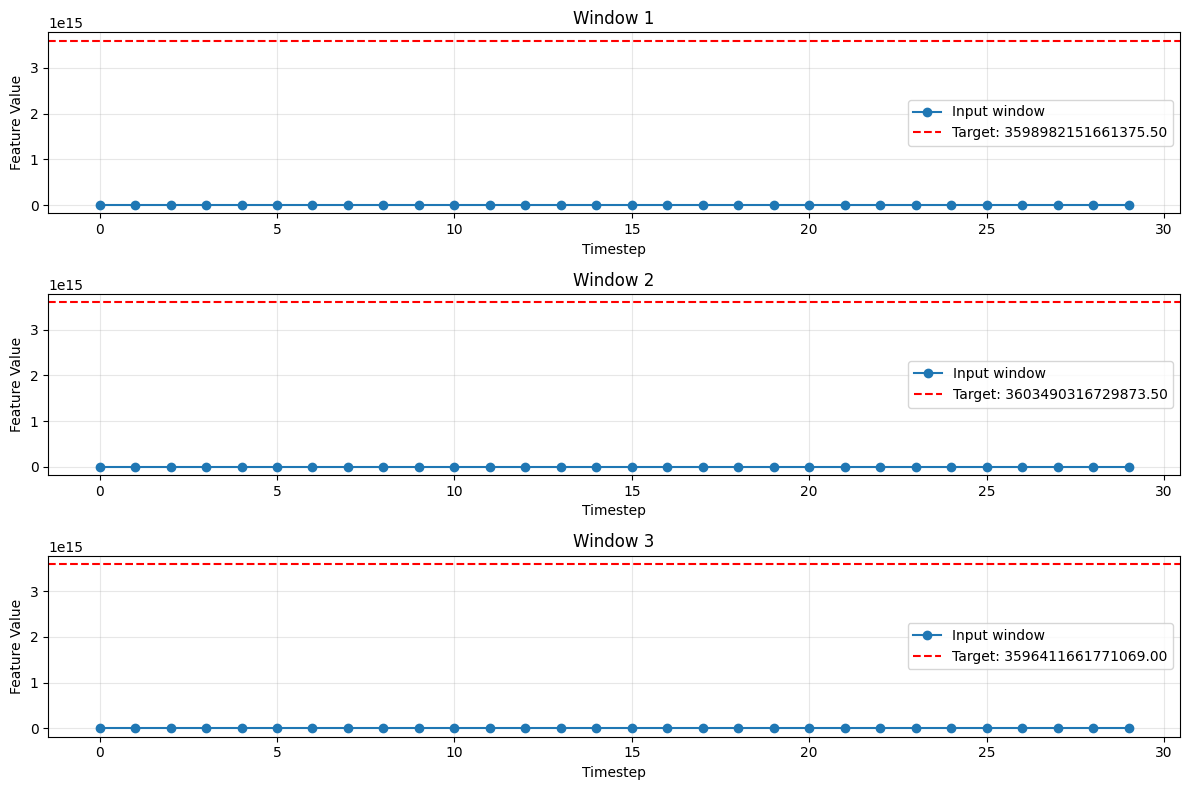

In [33]:
x_train_scaled,x_test_scaled,y_train,y_test,y_5_min_train,y_5_min_test,scaler,df,x_check_train_scaled,y_check_train,y_5_min_train_check,df_check=main_check()
visualize_windows(x_test_scaled[:3],y_test[:3],df,n_windows=3)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, Sequential,Model,optimizers,regularizers
from tensorflow.keras.layers import LSTM,Dense, Input, RepeatVector, TimeDistributed,Dropout
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

In [35]:

# BUGS FIXED - SEE COMMENTS BELOW
# ============================================================================
class SingleStepModels:
    @staticmethod
    def simple_lstm(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(256, activation='relu', input_shape=(window_size, n_features)),
            Dense(64, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        # BUG FIX #1: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model
    @staticmethod
    def stacked_lstm(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(32, activation='relu', return_sequences=True, input_shape=(window_size, n_features)),
            LSTM(16, activation='relu'),  # BUG FIX: Removed Dense layer (should be LSTM!)
            Dense(16, activation='relu'),
            Dense(8, activation='relu'),
            Dense(1)
        ])
        # BUG FIX #2: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model
    @staticmethod
    def lstm_with_dropout(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(256, activation='relu', return_sequences=True, input_shape=(window_size, n_features)),
            Dropout(0.2),
            LSTM(128, activation='relu', return_sequences=True),
            Dropout(0.2),
            LSTM(64, activation='relu'),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(1)
        ])
            
        # BUG FIX #3: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model
    @staticmethod
    def cnn_lstm(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)

        model = Sequential([
            # BUG FIX #4: Changed 'input=' → 'input_shape='
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, n_features)),
            layers.MaxPooling1D(pool_size=2),  # BUG FIX #5: MaxPool1D not MaxPooling1D (typo)
            LSTM(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        # BUG FIX #6: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model

In [36]:
# BUG FIX #7: Changed class name 'multiStepModels' → 'MultiStepModels' (capital M)
class MultiStepModels:
    @staticmethod
    def vector_output_lstm(window_size, n_features, forecast_horizon):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(10, activation='relu', input_shape=(window_size, n_features),kernel_regularizer=regularizers.l1_l2(l1=0.005,l2=0.001)),
            Dense(5, activation='relu'),
            Dense(forecast_horizon)
        ])
        # BUG FIX #8: Changed 'optimier' → 'optimizer'
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        return model
    @staticmethod
    def seq2seq_lstm(window_size, n_features, forecast_horizon):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        # Encoder
        encoder_inputs = Input(shape=(window_size, n_features))
        encoder_lstm = LSTM(10, return_state=True,kernel_regularizer=regularizers.l1_l2(l1=0.005,l2=0.001))
        encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
        encoder_states = [state_h, state_c]
        # Decoder
        decoder_inputs = Input(shape=(forecast_horizon, n_features))
        # BUG FIX #9: Changed return_state=True → return_sequences=True
        # (return_state returns hidden state, return_sequences returns full sequence)
        decoder_lstm = LSTM(10, return_sequences=True,kernel_regularizer=regularizers.l1_l2(l1=0.005,l2=0.001))
        decoder_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)
        decoder_dense = Dense(1)
        decoder_outputs = decoder_dense(decoder_outputs)
        model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
        # BUG FIX #10: Changed 'optimier' → 'optimizer'
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        return model
    @staticmethod
    def repeat_vector_lstm(window_size, n_features, forecast_horizon):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(10, activation='relu', input_shape=(window_size, n_features)),
            RepeatVector(forecast_horizon),
            LSTM(10, activation='relu', return_sequences=True),
            TimeDistributed(Dense(1))
        ])
        # BUG FIX #11: Changed 'optimier' → 'optimizer'
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        return model
    @staticmethod
    def transformer_lstm(window_size, n_features, forecast_horizon):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        inputs = Input(shape=(window_size, n_features))
        # Multi-head attention
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=32)
        attention_output = attention(inputs, inputs)
        # Add & normalize
        x = layers.Add()([inputs, attention_output])
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        # BUG FIX #12: Added Feed Forward Network (was missing!)
        ffn_output = Dense(8, activation='relu')(x)
        ffn_output = Dense(n_features)(ffn_output)
        x = layers.Add()([x, ffn_output])
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        # Global average pooling to reduce sequence to vector
        x = layers.GlobalAveragePooling1D()(x)
        # Output layer
        outputs = Dense(forecast_horizon)(x)
        model = Model(inputs=inputs, outputs=outputs)
        # BUG FIX #13: Changed 'optimier' → 'optimizer'
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        return model

In [37]:

# BUG FIX #14: Changed class name 'TraininUtils' → 'TrainingUtils'
class TrainingUtils:
    @staticmethod
    def get_callbacks(patience=1000, lr_factor=0.5):
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=patience,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(  # BUG FIX #15: Added this (was imported but not used)
                monitor='val_loss',
                factor=lr_factor,
                patience=5,
                min_lr=1e-6,
                verbose=1
            )
        ]
        return callbacks
    @staticmethod
    def train_single_step(model, x_train, y_train, x_val, y_val, epochs=1000, batch_size=32):
        history = model.fit(
            x_train, y_train,
            validation_data=(x_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=TrainingUtils.get_callbacks(),
            verbose=1
        )
        return history
    @staticmethod
    # BUG FIX #16: Changed parameter 'forecast_horion' → 'forecast_horizon'
    def train_multi_step_with_teacher_forcing(model, x_train, y_train, x_val, y_val, 
forecast_horizon, epochs=100, batch_size=32):
        history = model.fit(
            [x_train, y_train], y_train,
            validation_data=([x_val, y_val], y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=TrainingUtils.get_callbacks(),
            verbose=1
        )
        return history


In [38]:
class InferenceUtils:
    @staticmethod
    # BUG FIX #17: Changed parameter 'intial_window' → 'initial_window'
    def autoregressive_forecast(model, initial_window, steps_ahead, scaler=None):
        forecast = []
        current_window = initial_window.copy()
        for _ in range(steps_ahead):
            next_pred = model.predict(current_window, verbose=0)
            forecast.append(next_pred[0, 0])
            current_window = np.roll(current_window, -1, axis=1)
            current_window[0, -1, -1] = next_pred[0, 0]
        return np.array(forecast)
    @staticmethod
    def calculate_metrics(y_true, y_pred):
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


In [39]:
'''x_train_scaled,x_test_scaled,y_train,y_test
window_size=30
n_features=22
forecast_horizon=1
model = MultiStepModels.repeat_vector_lstm(window_size=window_size, n_features=n_features, forecast_horizon=forecast_horizon)
history = model.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test), epochs=1000, batch_size=128, callbacks=TrainingUtils.get_callbacks(), verbose=1)
'''


'x_train_scaled,x_test_scaled,y_train,y_test\nwindow_size=30\nn_features=22\nforecast_horizon=1\nmodel = MultiStepModels.repeat_vector_lstm(window_size=window_size, n_features=n_features, forecast_horizon=forecast_horizon)\nhistory = model.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test), epochs=1000, batch_size=128, callbacks=TrainingUtils.get_callbacks(), verbose=1)\n'

In [40]:
import tensorflow as tf

class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, name="CustomLoss", **kwargs):
        super(CustomLoss, self).__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        # Cast inputs to float32 to prevent precision errors
        y_true = tf.cast(y_true, dtype=tf.float32)
        y_pred = tf.cast(y_pred, dtype=tf.float32)
        
        # Flatten tensors to ensure accurate vector operations
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])
        
        # Calculate residual and total sum of squares
        mse = (tf.square(y_true - y_pred))
        mse=pd.Series(mse)
        mse_loss=0
        for i in mse:
            mse_loss=mse_loss+i
        
        mae = (y_true - y_pred)
        mae=pd.Series(mae)
        mae_loss=0
        for i in mae:
            mae_loss=mae_loss+i
        
        # Add epsilon (1e-8) to prevent division by zero errors
        loss=(mse_loss+mae_loss)/(y_true.shape[0]+1e-8)
        
        # Return 1 - R2 (minimizing this maximizes the R2 score)
        return loss


In [41]:
a=[0,1,2,3]
a=pd.Series(a)
a.shape[0]

4

In [42]:

# BUGS FIXED - SEE COMMENTS BELOW
# ============================================================================
class SingleStepModels:
    @staticmethod
    def simple_lstm(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(256, activation='relu', input_shape=(window_size, n_features)),
            Dense(64, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        # BUG FIX #1: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model
    @staticmethod
    def stacked_lstm(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(32, activation='relu', return_sequences=True, input_shape=(window_size, n_features)),
            LSTM(16, activation='relu'),  # BUG FIX: Removed Dense layer (should be LSTM!)
            Dense(16, activation='relu'),
            Dense(8, activation='relu'),
            Dense(1)
        ])
        # BUG FIX #2: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model
    @staticmethod
    def lstm_with_dropout(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)
        model = Sequential([
            LSTM(256, activation='relu', return_sequences=True, input_shape=(window_size, n_features)),
            Dropout(0.2),
            LSTM(128, activation='relu', return_sequences=True),
            Dropout(0.2),
            LSTM(64, activation='relu',return_sequences=True),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(1)
        ])
            
        # BUG FIX #3: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model
    @staticmethod
    def cnn_lstm(window_size, n_features):
        optimizer=optimizers.AdamW(weight_decay=0.004)

        model = Sequential([
            # BUG FIX #4: Changed 'input=' → 'input_shape='
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, n_features)),
            layers.MaxPooling1D(pool_size=2),  # BUG FIX #5: MaxPool1D not MaxPooling1D (typo)
            LSTM(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        # BUG FIX #6: Changed 'optimier' → 'optimizer'
        model.compile(optimizer='adam', loss='mae', metrics=['mae'])
        return model

In [43]:

# BUGS FIXED - SEE COMMENTS BELOW
# ============================================================================
class SingleStepModels:
    @staticmethod
    def cnn_lstm(window_size, n_features):
            optimizer=optimizers.AdamW(weight_decay=0.004)

            model = Sequential([
                # BUG FIX #4: Changed 'input=' → 'input_shape='
                layers.Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(window_size, n_features)),
                # BUG FIX #5: MaxPool1D not MaxPooling1D (typo)
                layers.MaxPooling1D(pool_size=2),
                LSTM(32, activation='relu',return_sequences=True),
                LSTM(16, activation='relu'),
                Dense(8, activation='relu'),
                Dense(4, activation='relu'),
                Dense(1)
            ])
            # BUG FIX #6: Changed 'optimier' → 'optimizer'
            model.compile(optimizer='adam', loss='mae', metrics=['mae'])
            return model
    
    @staticmethod
    def lstm_with_dropout(window_size, n_features):
            optimizer=optimizers.AdamW(weight_decay=0.004)
            model = Sequential([
                LSTM(256, activation='relu', return_sequences=True, input_shape=(window_size, n_features)),
                Dropout(0.2),
                LSTM(128, activation='relu', return_sequences=True),
                Dropout(0.2),
                LSTM(64, activation='relu',return_sequences=True),
                Dense(16, activation='relu'),
                Dropout(0.1),
                Dense(1)
            ])
                
            # BUG FIX #3: Changed 'optimier' → 'optimizer'
            model.compile(optimizer='adam', loss='mae', metrics=['mae'])
            return model

In [44]:
x_train_scaled,x_test_scaled,y_train,y_test
window_size=30
n_features=11
#3.55

#model=SingleStepModels.simple_lstm(window_size=window_size,n_features=n_features)
#model=SingleStepModels.stacked_lstm(window_size=window_size,n_features=n_features)
model=SingleStepModels.lstm_with_dropout(window_size=window_size,n_features=n_features)
#model=SingleStepModels.cnn_lstm(window_size=window_size,n_features=n_features)
print(model.summary())

history=TrainingUtils.train_single_step(model,x_train_scaled,y_train,x_test_scaled,y_test,epochs=50,batch_size=512)


c:\Users\HP\.pyenv\pyenv-win\versions\3.9.13\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 256)        │       274,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30, 16)         │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30, 1)          │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,017 (1.99 MB)

 Trainable params: 522,017 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 750ms/step - loss: 3376788113719296.0000 - mae: 3376789455896576.0000 - val_loss: 3683767143104512.0000 - val_mae: 3683767948410880.0000 - learning_rate: 0.0010
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 737ms/step - loss: 3375096970346496.0000 - mae: 3375095091298304.0000 - val_loss: 3679322925694976.0000 - val_mae: 3679323462565888.0000 - learning_rate: 0.0010
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 733ms/step - loss: 3331918590377984.0000 - mae: 3331919127248896.0000 - val_loss: 3560168990179328.0000 - val_mae: 3560169258614784.0000 - learning_rate: 0.0010
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 733ms/step - loss: 3252756437532672.0000 - mae: 3252757779709952.0000 - val_loss: 3522253555761152.0000 - val_mae: 3522253824196608.0000 - learning_rate: 0.0010
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 730ms/step - loss: 3229966804189184.0000 - mae: 3229966267318272.0000 - val_loss: 3513379884892160.0000 - val_mae: 3513379884892160.0000 - le

In [45]:
'''x_train_scaled,x_test_scaled,y_train,y_test
window_size=30
n_features=11

#model=SingleStepModels.simple_lstm(window_size=window_size,n_features=n_features)
#model=SingleStepModels.stacked_lstm(window_size=window_size,n_features=n_features)
#model=SingleStepModels.lstm_with_dropout(window_size=window_size,n_features=n_features)
model=SingleStepModels.cnn_lstm(window_size=window_size,n_features=n_features)
print(model.summary())

history=TrainingUtils.train_single_step(model,x_train_scaled,y_train,x_test_scaled,y_test,epochs=50,batch_size=512)'''


'x_train_scaled,x_test_scaled,y_train,y_test\nwindow_size=30\nn_features=11\n\n#model=SingleStepModels.simple_lstm(window_size=window_size,n_features=n_features)\n#model=SingleStepModels.stacked_lstm(window_size=window_size,n_features=n_features)\n#model=SingleStepModels.lstm_with_dropout(window_size=window_size,n_features=n_features)\nmodel=SingleStepModels.cnn_lstm(window_size=window_size,n_features=n_features)\nprint(model.summary())\n\nhistory=TrainingUtils.train_single_step(model,x_train_scaled,y_train,x_test_scaled,y_test,epochs=50,batch_size=512)'

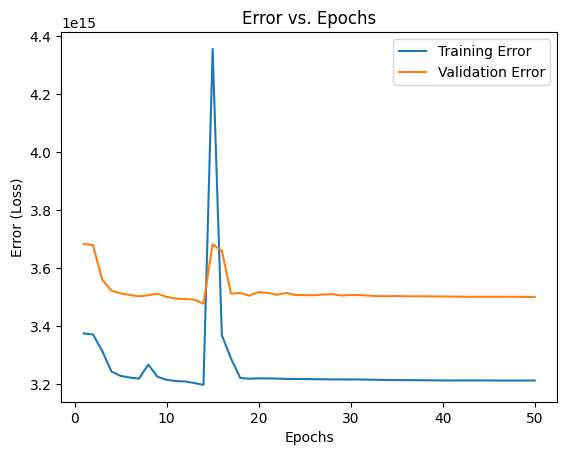

In [46]:

# 2. Extract loss data
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# 3. Create the plot
plt.plot(epochs, train_loss , label='Training Error')
plt.plot(epochs, val_loss, label='Validation Error')
plt.title('Error vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error (Loss)')
plt.legend()



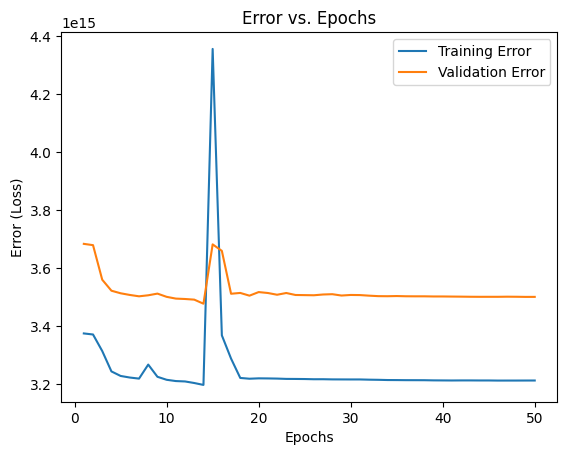

In [47]:

# 2. Extract metrics data
train_loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(train_loss) + 1)

# 3. Create the plot
plt.plot(epochs, train_loss , label='Training Error')
plt.plot(epochs, val_loss, label='Validation Error')
plt.title('Error vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error (Loss)')
plt.legend()

In [48]:
y_5_min_train.shape

(12189, 30)

In [49]:
y_5_min_train.shape[0]

12189

In [50]:
y_5_min_train[0,:].mean()

3659512309284056.5

In [51]:
y_5_min_train_mean_vals=[]
for i in range(y_5_min_train.shape[0]):
    y_5_min_train_mean_vals.append(y_5_min_train[i,:].mean())

y_5_min_train_mean_vals=np.array(y_5_min_train_mean_vals)

In [52]:
pred=model.predict(x_train_scaled)

381/381 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step


In [53]:
i=3.55

381/381 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step
3.55


ValueError: x and y can be no greater than 2D, but have shapes (12189,) and (12189, 30, 1)

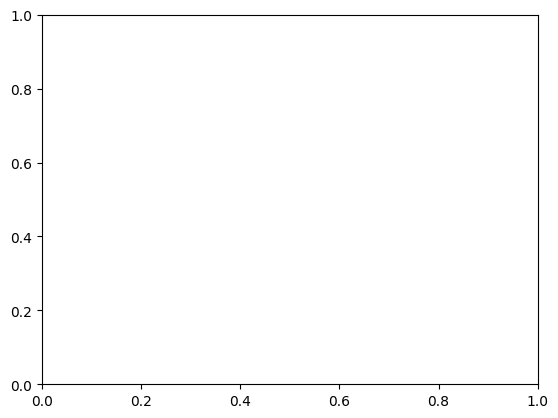

In [54]:
pred=model.predict(x_train_scaled)
y_original=y_train
print(i)
plt.plot(pred**(1/i))
plt.plot(y_original**(1/i))
plt.plot(y_5_min_train_mean_vals**(1/i))



In [ ]:
y_5_min_train.shape

(12189, 30)

In [ ]:
y_5_min_test_mean_vals=[]
for i in range(y_5_min_test.shape[0]):
    y_5_min_test_mean_vals.append(y_5_min_test[i,:].mean())

y_5_min_test_mean_vals=np.array(y_5_min_test_mean_vals)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


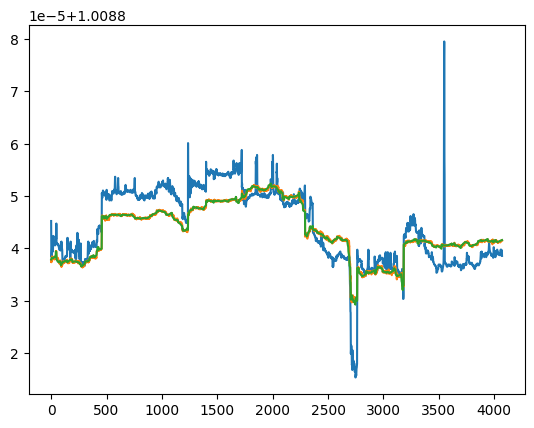

In [ ]:
pred=model.predict(x_test_scaled)
y_original=y_test
plt.plot(pred**(1/i))
plt.plot(y_original**(1/i))
plt.plot(y_5_min_test_mean_vals**(1/i))


In [ ]:
y_5_min_train_check.shape

(2850, 30)

In [ ]:
y_5_min_train_check_mean_vals=[]
for i in range(y_5_min_train_check.shape[0]):
    y_5_min_train_check_mean_vals.append(y_5_min_train_check[i,:].mean())

y_5_min_train_check_mean_vals=np.array(y_5_min_train_check_mean_vals)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


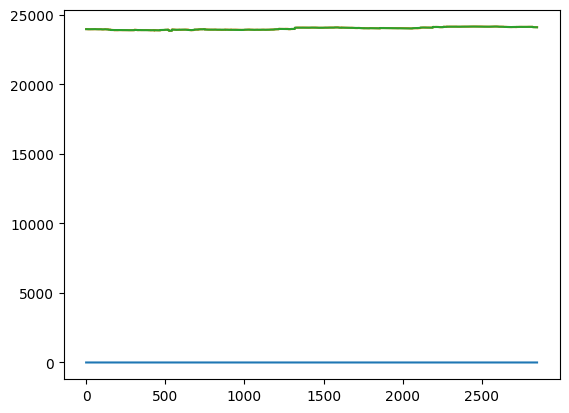

In [ ]:
pred=model.predict(x_check_train_scaled)
y_original=y_check_train
plt.plot(pred**(1/i))
plt.plot(y_original**(1/3.55))
plt.plot(y_5_min_train_check_mean_vals**(1/3.55))

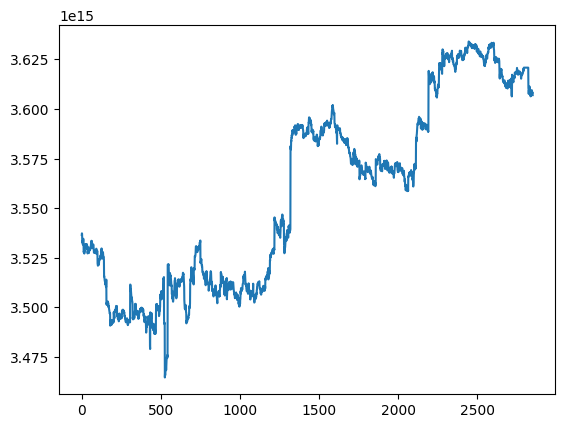

In [ ]:
plt.plot(y_original)

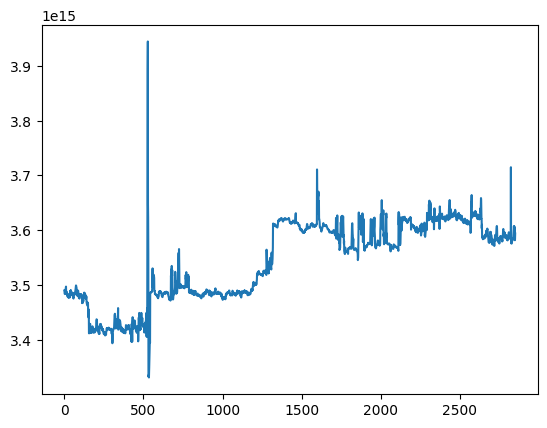

In [ ]:
plt.plot(pred)

In [ ]:
#model.save('dom_47_cnn_lstm_best.h5')